EXPERIMENT 07 - TASK 03
Machine Learning Pipeline
Name    : R. Karthik
Roll No : 25EU02904

Best Pipeline Parameters:
{'classifier__C': 1, 'classifier__gamma': 0.01, 'imputer__strategy': 'median'}

Best CV F1 Score: 0.7631

Pipeline Test Accuracy: 74.03%

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.75      0.79       100
           1       0.61      0.72      0.66        54

    accuracy                           0.74       154
   macro avg       0.72      0.74      0.73       154
weighted avg       0.75      0.74      0.74       154


Confusion Matrix:
[[75 25]
 [15 39]]


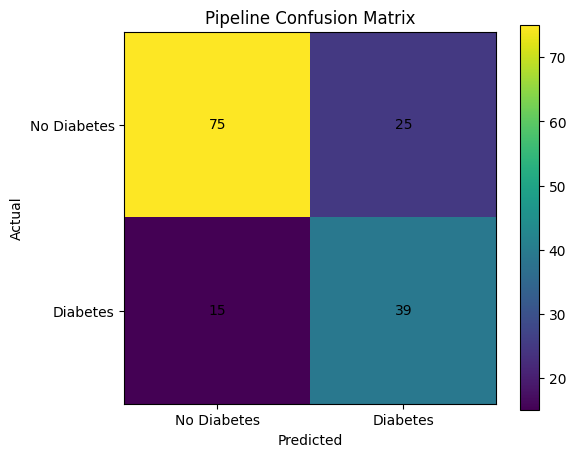


Pipeline saved as: pima_diabetes_pipeline.joblib

Reloaded Pipeline Prediction: 1

TASK 03 COMPLETED
Name    : R. Karthik
Roll No : 25EU02904


In [1]:
# ============================================================
# EXPERIMENT 07 - TASK 03
# Machine Learning Pipeline
#
# Name    : R. Karthik
# Roll No : 25EU02904
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("=" * 60)
print("EXPERIMENT 07 - TASK 03")
print("Machine Learning Pipeline")
print("Name    : R. Karthik")
print("Roll No : 25EU02904")
print("=" * 60)

# ------------------------------------------------------------
# Load Pima Dataset
# ------------------------------------------------------------

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

df = pd.read_csv(
    url,
    header=None,
    names=columns
)

X = df.drop(
    "Outcome",
    axis=1
).copy()

y = df["Outcome"]

# ------------------------------------------------------------
# Replace invalid zeros with NaN
# ------------------------------------------------------------

invalid_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

X[invalid_columns] = (
    X[invalid_columns]
    .replace(0, np.nan)
)

# ------------------------------------------------------------
# Train-Test Split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# ------------------------------------------------------------
# Build Pipeline
# ------------------------------------------------------------

pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        ),
        (
            "classifier",
            SVC(
                probability=True,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

# ------------------------------------------------------------
# Pipeline Hyperparameter Grid
# ------------------------------------------------------------

param_grid = {
    "imputer__strategy": [
        "mean",
        "median"
    ],
    "classifier__C": [
        0.1,
        1,
        5,
        10
    ],
    "classifier__gamma": [
        "scale",
        "auto",
        0.01,
        0.1
    ]
}

# ------------------------------------------------------------
# Grid Search on Pipeline
# ------------------------------------------------------------

grid = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid.fit(
    X_train,
    y_train
)

best_pipeline = grid.best_estimator_

print("\nBest Pipeline Parameters:")
print(
    grid.best_params_
)

print(
    f"\nBest CV F1 Score: "
    f"{grid.best_score_:.4f}"
)

# ------------------------------------------------------------
# Test Evaluation
# ------------------------------------------------------------

predictions = best_pipeline.predict(
    X_test
)

accuracy = accuracy_score(
    y_test,
    predictions
)

print(
    f"\nPipeline Test Accuracy: "
    f"{accuracy * 100:.2f}%"
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        predictions
    )
)

# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_test,
    predictions
)

print("\nConfusion Matrix:")
print(cm)

plt.figure(
    figsize=(6, 5)
)

plt.imshow(
    cm,
    interpolation="nearest"
)

plt.title(
    "Pipeline Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.colorbar()

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.xticks(
    [0, 1],
    ["No Diabetes", "Diabetes"]
)

plt.yticks(
    [0, 1],
    ["No Diabetes", "Diabetes"]
)

plt.show()

# ------------------------------------------------------------
# Save Pipeline
# ------------------------------------------------------------

filename = (
    "pima_diabetes_pipeline.joblib"
)

joblib.dump(
    best_pipeline,
    filename
)

print(
    f"\nPipeline saved as: {filename}"
)

# ------------------------------------------------------------
# Reload Pipeline
# ------------------------------------------------------------

loaded_pipeline = joblib.load(
    filename
)

sample = pd.DataFrame([{
    "Pregnancies": 1,
    "Glucose": 189,
    "BloodPressure": 60,
    "SkinThickness": 0,
    "Insulin": 0,
    "BMI": 30.1,
    "DiabetesPedigreeFunction": 0.398,
    "Age": 59
}])

sample[invalid_columns] = (
    sample[invalid_columns]
    .replace(0, np.nan)
)

sample_prediction = (
    loaded_pipeline.predict(sample)
)

print(
    "\nReloaded Pipeline Prediction:",
    sample_prediction[0]
)

print("\n" + "=" * 60)
print("TASK 03 COMPLETED")
print("Name    : R. Karthik")
print("Roll No : 25EU02904")
print("=" * 60)